In [ ]:
# ================================
# CARREGANDO O DATASET
# ================================

#dados = pd.read_csv('../data/raw/Customer-Churn.csv',sep = ',', encoding = 'utf-8',header=0)

In [ ]:
#Dados pre processados salvos na pasta processed
#dados_final.to_csv('../data/processed/Customer-Churn-processed.csv', index=False)

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Conjuge                                       7043 non-null   int64  
 1   Dependentes                                   7043 non-null   int64  
 2   TelefoneFixo                                  7043 non-null   int64  
 3   PagamentoOnline                               7043 non-null   int64  
 4   Churn                                         7043 non-null   int64  
 5   Maior65Anos                                   7043 non-null   int64  
 6   MesesDeContrato                               7043 non-null   int64  
 7   ContaMensal                                   7043 non-null   float64
 8   VariasLinhasTelefonicas_Nao                   7043 non-null   bool   
 9   VariasLinhasTelefonicas_SemServicoTelefonico  7043 non-null   b

/tmp/ipykernel_30601/3302947372.py:55: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)


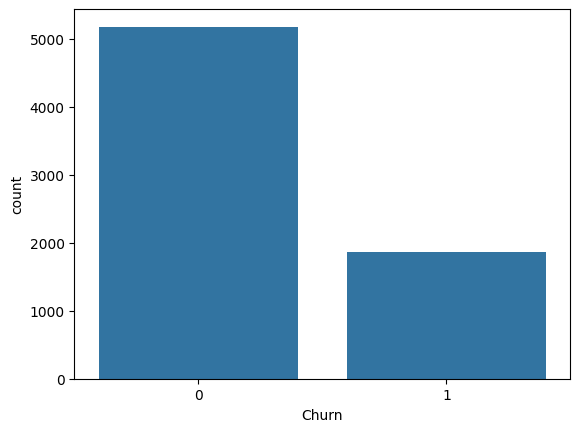


Distribuição do target:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


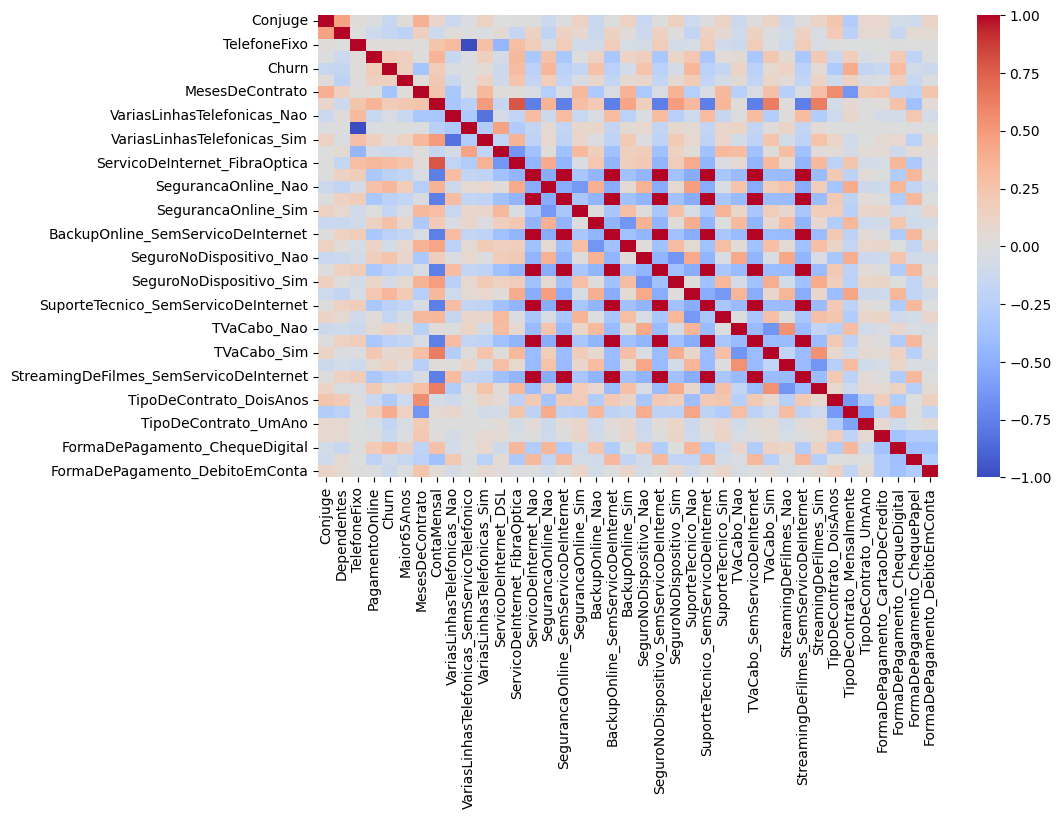

2026/04/06 10:50:18 ERROR mlflow.store.db.utils: SQLAlchemy database error. The following exception is caught.
(raised as a result of Query-invoked autoflush; consider using a session.no_autoflush block if this flush is occurring prematurely)
(sqlite3.OperationalError) attempt to write a readonly database
[SQL: INSERT INTO runs (run_uuid, name, source_type, source_name, entry_point_name, user_id, status, start_time, end_time, deleted_time, source_version, lifecycle_stage, artifact_uri, experiment_id) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)]
[parameters: ('c74fb800cee446648d9fe929944e65c9', 'dummy_baseline', 'UNKNOWN', '', '', 'rafa_exmaquina', 'RUNNING', 1775483418078, None, None, '', 'active', 'file://home/rafa_exmaquina/Documentos/churn-prediction/mlruns/c74fb800cee446648d9fe929944e65c9/artifacts', '1')]
(Background on this error at: https://sqlalche.me/e/20/e3q8)
Traceback (most recent call last):
  File "/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12


Informações do Dataset:
Total de amostras: 7043
Shape dos dados: (7043, 38)


MlflowException: (raised as a result of Query-invoked autoflush; consider using a session.no_autoflush block if this flush is occurring prematurely)
(sqlite3.OperationalError) attempt to write a readonly database
[SQL: INSERT INTO runs (run_uuid, name, source_type, source_name, entry_point_name, user_id, status, start_time, end_time, deleted_time, source_version, lifecycle_stage, artifact_uri, experiment_id) VALUES (?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?, ?)]
[parameters: ('c74fb800cee446648d9fe929944e65c9', 'dummy_baseline', 'UNKNOWN', '', '', 'rafa_exmaquina', 'RUNNING', 1775483418078, None, None, '', 'active', 'file://home/rafa_exmaquina/Documentos/churn-prediction/mlruns/c74fb800cee446648d9fe929944e65c9/artifacts', '1')]
(Background on this error at: https://sqlalche.me/e/20/e3q8)

In [6]:
# ================================
# IMPORTANDO BIBLIOTECAS
# ================================

import pandas as pd
import numpy as np
import os
import mlflow



import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, f1_score



# ================================
# CONFIGURAÇÃO DO MLFLOW
# ================================

BASE_DIR = os.path.abspath("..")

os.environ["MLFLOW_TRACKING_URI"] = f"sqlite:///{BASE_DIR}/mlflow.db"
os.environ["MLFLOW_ARTIFACT_URI"] = f"file:///{BASE_DIR}/mlruns"

mlflow.set_tracking_uri(os.environ["MLFLOW_TRACKING_URI"])
mlflow.set_registry_uri(os.environ["MLFLOW_TRACKING_URI"])

mlflow.set_experiment("churn_baseline")

# ================================
# CARREGANDO O DATASET
# ================================

dados = pd.read_csv('../data/raw/Customer-Churn.csv', sep=',', encoding='utf-8')


# ================================
# TRATAMENTO DOS DADOS
# ================================

traducao_dic = {'Sim': 1, 'Nao': 0}

dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)

dummie_dados = pd.get_dummies(
    dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'], axis=1)
)

dados_final = pd.concat([dadosmodificados, dummie_dados], axis=1)


# ================================
# EDA
# ================================

print(dados_final.info())
print(dados_final.describe())

print("\nMissing values:")
print(dados_final.isnull().sum())

sns.countplot(x='Churn', data=dados_final)
plt.show()

print("\nDistribuição do target:")
print(dados_final['Churn'].value_counts(normalize=True))

plt.figure(figsize=(10,6))
sns.heatmap(dados_final.corr(), annot=False, cmap='coolwarm')
plt.show()


# ================================
# FEATURES E TARGET
# ================================

X = dados_final.drop('Churn', axis=1)
y = dados_final['Churn']

print("\nInformações do Dataset:")
print(f"Total de amostras: {len(X)}")
print(f"Shape dos dados: {X.shape}")

# Salvar dataset processado
dados_final.to_csv('../data/processed/Customer-Churn-processed.csv', index=False)


# ================================
# SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ================================
# PIPELINE (AGORA SOMENTE NUMÉRICO)
# ================================

pipeline_base = Pipeline([
    ('scaler', StandardScaler())
])


# ================================
# FUNÇÃO PARA TREINAR + LOGAR
# ================================

def train_and_log_model(model, model_name):
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    with mlflow.start_run(run_name=model_name):
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        mlflow.log_param("model", model_name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        
        mlflow.sklearn.log_model(pipeline, "model")
        
        print(f"\n=== {model_name} ===")
        print("Accuracy:", acc)
        print("F1 Score:", f1)
        print(classification_report(y_test, y_pred))


# ================================
# TREINANDO MODELOS
# ================================

# Baseline
train_and_log_model(
    DummyClassifier(strategy='most_frequent'),
    "dummy_baseline"
)

# Logistic Regression
train_and_log_model(
    LogisticRegression(max_iter=1000),
    "logistic_regression"
)

# Random Forest
train_and_log_model(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "random_forest"
)

# XGBoost
train_and_log_model(
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ),
    "xgboost"
)

2026/04/06 10:54:48 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/06 10:54:48 INFO mlflow.store.db.utils: Updating database tables


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Conjuge                                       7043 non-null   int64  
 1   Dependentes                                   7043 non-null   int64  
 2   TelefoneFixo                                  7043 non-null   int64  
 3   PagamentoOnline                               7043 non-null   int64  
 4   Churn                                         7043 non-null   int64  
 5   Maior65Anos                                   7043 non-null   int64  
 6   MesesDeContrato                               7043 non-null   int64  
 7   ContaMensal                                   7043 non-null   float64
 8   VariasLinhasTelefonicas_Nao                   7043 non-null   bool   
 9   VariasLinhasTelefonicas_SemServicoTelefonico  7043 non-null   b

/tmp/ipykernel_180156/4228313525.py:69: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)


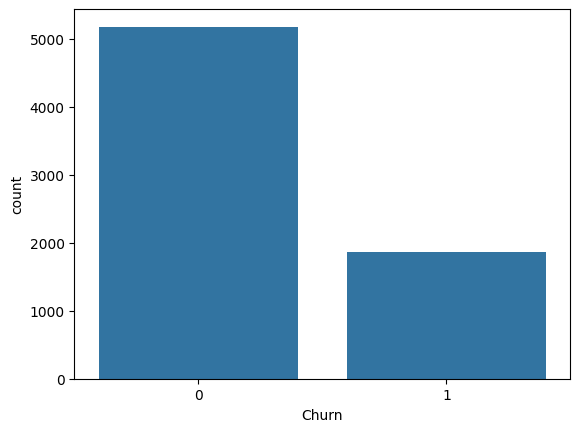


Distribuição do target:
Churn
0    0.73463
1    0.26537
Name: proportion, dtype: float64


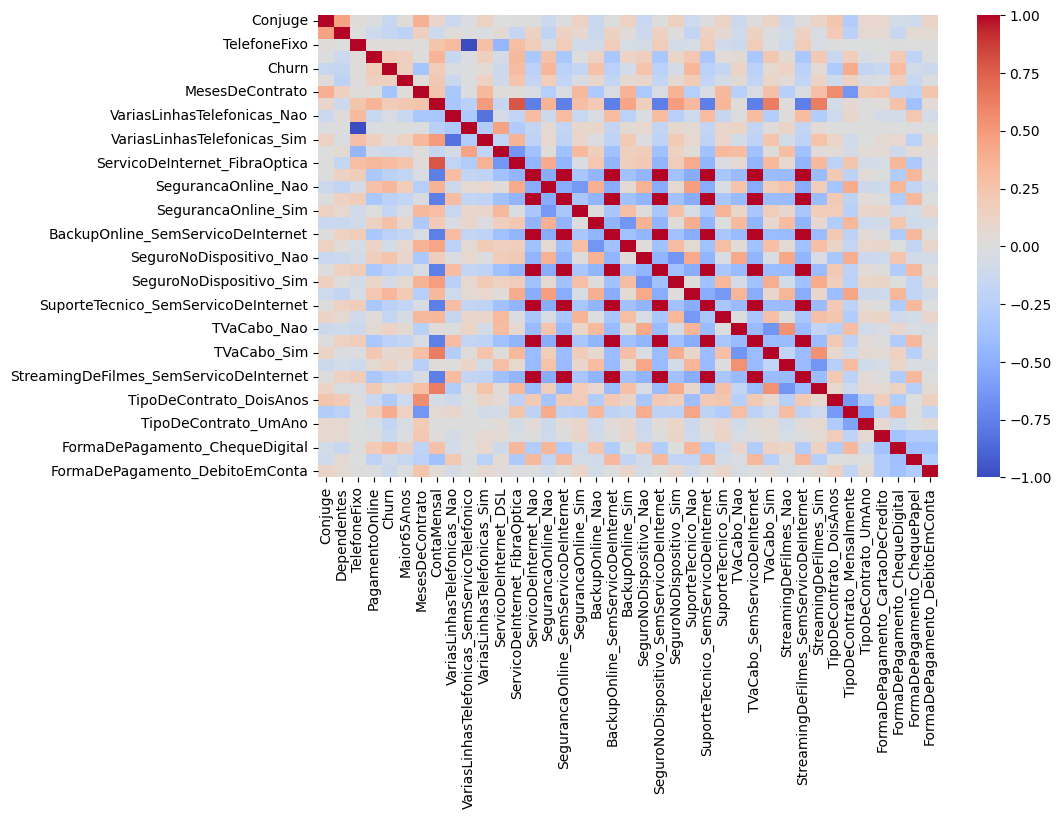


Informações do Dataset:
Total de amostras: 7043
Shape dos dados: (7043, 38)


2026/04/06 10:54:50 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 10:54:50 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== dummy_baseline ===
Accuracy: 0.7345635202271115
F1 Score: 0.0
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 


=== logistic_regression ===
Accuracy: 0.7977288857345636
F1 Score: 0.5899280575539568
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



2026/04/06 10:54:58 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 10:54:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== random_forest ===
Accuracy: 0.7814052519517388
F1 Score: 0.5510204081632653
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [10:55:02] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/06 10:55:06 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 10:55:06 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== xgboost ===
Accuracy: 0.7863733144073811
F1 Score: 0.5681492109038737
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [1]:
# ================================
# IMPORTANDO BIBLIOTECAS
# ================================

import pandas as pd
import numpy as np
import os
import mlflow
from mlflow.tracking import MlflowClient

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, f1_score


# ================================
# CONFIGURAÇÃO DO MLFLOW (CORRETA)
# ================================

BASE_DIR = os.path.abspath("..")

# Define banco SQLite na raiz
TRACKING_URI = f"sqlite:///{BASE_DIR}/mlflow.db"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)

client = MlflowClient()

experiment_name = "churn_baseline"

# 🔥 Deleta experimento antigo (evita caminho errado)
exp = client.get_experiment_by_name(experiment_name)
if exp is not None:
    client.delete_experiment(exp.experiment_id)

# 🔥 Cria com artifact na raiz
client.create_experiment(
    experiment_name,
    artifact_location=f"file://{BASE_DIR}/mlruns"
)

mlflow.set_experiment(experiment_name)


# ================================
# CARREGANDO O DATASET
# ================================

dados = pd.read_csv('../data/raw/Customer-Churn.csv', sep=',', encoding='utf-8')


# ================================
# TRATAMENTO DOS DADOS
# ================================

traducao_dic = {'Sim': 1, 'Nao': 0}

dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)

dummie_dados = pd.get_dummies(
    dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'], axis=1)
)

dados_final = pd.concat([dadosmodificados, dummie_dados], axis=1)


# ================================
# EDA
# ================================

print(dados_final.info())
print(dados_final.describe())

print("\nMissing values:")
print(dados_final.isnull().sum())

sns.countplot(x='Churn', data=dados_final)
plt.show()

print("\nDistribuição do target:")
print(dados_final['Churn'].value_counts(normalize=True))

plt.figure(figsize=(10,6))
sns.heatmap(dados_final.corr(), annot=False, cmap='coolwarm')
plt.show()


# ================================
# FEATURES E TARGET
# ================================

X = dados_final.drop('Churn', axis=1)
y = dados_final['Churn']

print("\nInformações do Dataset:")
print(f"Total de amostras: {len(X)}")
print(f"Shape dos dados: {X.shape}")

# Salvar dataset processado
dados_final.to_csv('../data/processed/Customer-Churn-processed.csv', index=False)


# ================================
# SPLIT
# ================================

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


# ================================
# FUNÇÃO PARA TREINAR + LOGAR
# ================================

def train_and_log_model(model, model_name):
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    with mlflow.start_run(run_name=model_name):
        
        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)
        
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        
        mlflow.log_param("model", model_name)
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        
        mlflow.sklearn.log_model(pipeline, "model")
        
        print(f"\n=== {model_name} ===")
        print("Accuracy:", acc)
        print("F1 Score:", f1)
        print(classification_report(y_test, y_pred))


# ================================
# TREINANDO MODELOS
# ================================

train_and_log_model(
    DummyClassifier(strategy='most_frequent'),
    "dummy_baseline"
)

train_and_log_model(
    LogisticRegression(max_iter=1000),
    "logistic_regression"
)

train_and_log_model(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "random_forest"
)

train_and_log_model(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "xgboost"
)

#Versão Final Etapa 1

In [1]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import os
import mlflow
from mlflow.tracking import MlflowClient

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    f1_score,
    roc_auc_score,
    average_precision_score
)

# ================================
# CONFIG MLFLOW
# ================================
BASE_DIR = os.path.abspath("..")
TRACKING_URI = f"sqlite:///{BASE_DIR}/mlflow.db"

mlflow.set_tracking_uri(TRACKING_URI)
mlflow.set_registry_uri(TRACKING_URI)

client = MlflowClient()
experiment_name = "churn_baseline"

exp = client.get_experiment_by_name(experiment_name)
if exp is not None:
    client.delete_experiment(exp.experiment_id)

client.create_experiment(
    experiment_name,
    artifact_location=f"file://{BASE_DIR}/mlruns"
)

mlflow.set_experiment(experiment_name)

# ================================
# CARREGANDO DADOS
# ================================
dados = pd.read_csv('../data/raw/Customer-Churn.csv', sep=',', encoding='utf-8')

# ================================
# TRATAMENTO
# ================================
traducao_dic = {'Sim': 1, 'Nao': 0}

dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)

dummie_dados = pd.get_dummies(
    dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'], axis=1)
)

dados_final = pd.concat([dadosmodificados, dummie_dados], axis=1)

# ================================
# EDA
# ================================
print(dados_final.info())
print(dados_final.describe())

print("\nMissing values:")
print(dados_final.isnull().sum())

sns.countplot(x='Churn', data=dados_final)
plt.savefig("churn_distribution.png")
plt.close()

plt.figure(figsize=(10,6))
sns.heatmap(dados_final.corr(), cmap='coolwarm')
plt.savefig("correlation_heatmap.png")
plt.close()

# ================================
# FEATURES
# ================================
X = dados_final.drop('Churn', axis=1)
y = dados_final['Churn']

dados_final.to_csv('../data/processed/Customer-Churn-processed.csv', index=False)

# ================================
# SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# FUNÇÃO DE NEGÓCIO
# ================================
def business_metric(y_true, y_pred):
    custo_churn = 500
    custo_retencao = 100

    tp = ((y_true == 1) & (y_pred == 1)).sum()

    lucro = tp * (custo_churn - custo_retencao)
    return lucro

# ================================
# FUNÇÃO TREINO + LOG
# ================================
def train_and_log_model(model, model_name):
    
    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])
    
    with mlflow.start_run(run_name=model_name):
        
        pipeline.fit(X_train, y_train)
        
        y_pred = pipeline.predict(X_test)
        y_proba = pipeline.predict_proba(X_test)[:, 1]
        
        # Métricas
        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)
        roc_auc = roc_auc_score(y_test, y_proba)
        pr_auc = average_precision_score(y_test, y_proba)
        lucro = business_metric(y_test, y_pred)
        
        # LOG
        mlflow.log_param("model", model_name)
        mlflow.log_params(model.get_params())
        mlflow.log_param("dataset_version", "v1")
        
        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)
        mlflow.log_metric("roc_auc", roc_auc)
        mlflow.log_metric("pr_auc", pr_auc)
        mlflow.log_metric("business_profit", lucro)
        
        # artifacts
        mlflow.log_artifact("churn_distribution.png")
        mlflow.log_artifact("correlation_heatmap.png")
        
        mlflow.sklearn.log_model(pipeline, "model")
        
        print(f"\n=== {model_name} ===")
        print("Accuracy:", acc)
        print("F1:", f1)
        print("ROC-AUC:", roc_auc)
        print("PR-AUC:", pr_auc)
        print("Lucro:", lucro)
        print(classification_report(y_test, y_pred))


# ================================
# MODELOS
# ================================
train_and_log_model(
    DummyClassifier(strategy='most_frequent'),
    "dummy_baseline"
)

train_and_log_model(
    LogisticRegression(max_iter=1000),
    "logistic_regression"
)

train_and_log_model(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "random_forest"
)

train_and_log_model(
    XGBClassifier(
        use_label_encoder=False,
        eval_metric='logloss',
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        random_state=42
    ),
    "xgboost"
)

2026/04/06 17:42:08 INFO mlflow.store.db.utils: Creating initial MLflow database tables...
2026/04/06 17:42:08 INFO mlflow.store.db.utils: Updating database tables
/tmp/ipykernel_3040876/1374647034.py:63: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 39 columns):
 #   Column                                        Non-Null Count  Dtype  
---  ------                                        --------------  -----  
 0   Conjuge                                       7043 non-null   int64  
 1   Dependentes                                   7043 non-null   int64  
 2   TelefoneFixo                                  7043 non-null   int64  
 3   PagamentoOnline                               7043 non-null   int64  
 4   Churn                                         7043 non-null   int64  
 5   Maior65Anos                                   7043 non-null   int64  
 6   MesesDeContrato                               7043 non-null   int64  
 7   ContaMensal                                   7043 non-null   float64
 8   VariasLinhasTelefonicas_Nao                   7043 non-null   bool   
 9   VariasLinhasTelefonicas_SemServicoTelefonico  7043 non-null   b

2026/04/06 17:42:11 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 17:42:11 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== dummy_baseline ===
Accuracy: 0.7345635202271115
F1: 0.0
ROC-AUC: 0.5
PR-AUC: 0.2654364797728886
Lucro: 0
              precision    recall  f1-score   support

           0       0.73      1.00      0.85      1035
           1       0.00      0.00      0.00       374

    accuracy                           0.73      1409
   macro avg       0.37      0.50      0.42      1409
weighted avg       0.54      0.73      0.62      1409



/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control 


=== logistic_regression ===
Accuracy: 0.7977288857345636
F1: 0.5899280575539568
ROC-AUC: 0.8390684336975898
PR-AUC: 0.6296566284934224
Lucro: 82000
              precision    recall  f1-score   support

           0       0.84      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



2026/04/06 17:42:20 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 17:42:20 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== random_forest ===
Accuracy: 0.7814052519517388
F1: 0.5510204081632653
ROC-AUC: 0.8109690252912759
PR-AUC: 0.5969318675295802
Lucro: 75600
              precision    recall  f1-score   support

           0       0.83      0.88      0.86      1035
           1       0.61      0.51      0.55       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



/home/rafa_exmaquina/Documentos/churn-prediction/.env/lib/python3.12/site-packages/xgboost/training.py:200: UserWarning: [17:42:24] WARNING: /__w/xgboost/xgboost/src/learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)
2026/04/06 17:42:28 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 17:42:28 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== xgboost ===
Accuracy: 0.7863733144073811
F1: 0.5681492109038737
ROC-AUC: 0.8273747707251544
PR-AUC: 0.6304383821200248
Lucro: 79200
              precision    recall  f1-score   support

           0       0.84      0.88      0.86      1035
           1       0.61      0.53      0.57       374

    accuracy                           0.79      1409
   macro avg       0.73      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



In [2]:
# ================================
# IMPORTS
# ================================
import pandas as pd
import numpy as np
import os
import mlflow
import mlflow.sklearn

from mlflow.tracking import MlflowClient

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

from sklearn.dummy import DummyClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier

from sklearn.metrics import accuracy_score, classification_report, f1_score

# ================================
# CONFIG MLFLOW GLOBAL (PADRÃO CERTO)
# ================================
BASE_DIR = os.path.abspath("..")

mlflow.set_tracking_uri(f"sqlite:///{BASE_DIR}/mlflow.db")
mlflow.set_registry_uri(f"sqlite:///{BASE_DIR}/mlflow.db")

mlflow.set_experiment("churn_project")

client = MlflowClient()

# ================================
# DADOS
# ================================
dados = pd.read_csv(f"{BASE_DIR}/data/raw/Customer-Churn.csv", sep=',', encoding='utf-8')

traducao_dic = {'Sim': 1, 'Nao': 0}

dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)

dummie_dados = pd.get_dummies(
    dados.drop(['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn'], axis=1)
)

dados_final = pd.concat([dadosmodificados, dummie_dados], axis=1)

# ================================
# FEATURES
# ================================
X = dados_final.drop('Churn', axis=1)
y = dados_final['Churn']

dados_final.to_csv(f"{BASE_DIR}/data/processed/Customer-Churn-processed.csv", index=False)

# ================================
# SPLIT
# ================================
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# ================================
# FUNÇÃO TREINO + REGISTRY
# ================================
def train_log_and_register(model, model_name, registry_name):

    pipeline = Pipeline([
        ('scaler', StandardScaler()),
        ('model', model)
    ])

    with mlflow.start_run(run_name=model_name) as run:

        pipeline.fit(X_train, y_train)
        y_pred = pipeline.predict(X_test)

        acc = accuracy_score(y_test, y_pred)
        f1 = f1_score(y_test, y_pred)

        # ========================
        # LOG
        # ========================
        mlflow.log_param("model", model_name)
        mlflow.log_params(model.get_params())

        mlflow.log_metric("accuracy", acc)
        mlflow.log_metric("f1_score", f1)

        mlflow.sklearn.log_model(pipeline, "model")

        run_id = run.info.run_id
        model_uri = f"runs:/{run_id}/model"

        print(f"\n=== {model_name} ===")
        print("Accuracy:", acc)
        print("F1 Score:", f1)

    # ========================
    # REGISTRY
    # ========================
    try:
        client.create_registered_model(registry_name)
    except:
        print(f"{registry_name} já existe")

    model_version = client.create_model_version(
        name=registry_name,
        source=model_uri,
        run_id=run_id
    )

    print(f"Registrado: {registry_name} v{model_version.version}")

    return model_version.version, acc

# ================================
# TREINAR MODELOS
# ================================
results = {}

# Dummy
version, acc = train_log_and_register(
    DummyClassifier(strategy='most_frequent'),
    "dummy_baseline",
    "churn_dummy"
)
results["dummy"] = (version, acc)

# Logistic Regression
version, acc = train_log_and_register(
    LogisticRegression(max_iter=1000),
    "logistic_regression",
    "churn_logreg"
)
results["logreg"] = (version, acc)

# Random Forest
version, acc = train_log_and_register(
    RandomForestClassifier(
        n_estimators=200,
        random_state=42,
        n_jobs=-1
    ),
    "random_forest",
    "churn_rf"
)
results["rf"] = (version, acc)

# XGBoost
version, acc = train_log_and_register(
    XGBClassifier(
        n_estimators=300,
        max_depth=6,
        learning_rate=0.05,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='logloss',
        random_state=42
    ),
    "xgboost",
    "churn_xgb"
)
results["xgb"] = (version, acc)

# ================================
# PROMOVER MELHOR MODELO
# ================================
best_model = max(results, key=lambda x: results[x][1])
best_version = results[best_model][0]

registry_map = {
    "dummy": "churn_dummy",
    "logreg": "churn_logreg",
    "rf": "churn_rf",
    "xgb": "churn_xgb"
}

best_registry = registry_map[best_model]

client.transition_model_version_stage(
    name=best_registry,
    version=best_version,
    stage="Production"
)

print(f"\n🔥 Melhor modelo ({best_model}) promovido para PRODUÇÃO!")

/tmp/ipykernel_3040876/1641864908.py:45: FutureWarning: Downcasting behavior in `replace` is deprecated and will be removed in a future version. To retain the old behavior, explicitly call `result.infer_objects(copy=False)`. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  dadosmodificados = dados[['Conjuge', 'Dependentes', 'TelefoneFixo', 'PagamentoOnline', 'Churn']].replace(traducao_dic)
2026/04/06 19:47:54 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:47:54 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html
2026/04/06 19:47:58 WARNING mlflow.models.model: `arti


=== dummy_baseline ===
Accuracy: 0.7345635202271115
F1 Score: 0.0
Registrado: churn_dummy v1


2026/04/06 19:47:58 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== logistic_regression ===
Accuracy: 0.7977288857345636
F1 Score: 0.5899280575539568
Registrado: churn_logreg v1


2026/04/06 19:48:02 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:48:02 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== random_forest ===
Accuracy: 0.7814052519517388
F1 Score: 0.5510204081632653
Registrado: churn_rf v1


2026/04/06 19:48:10 WARNING mlflow.models.model: `artifact_path` is deprecated. Please use `name` instead.
2026/04/06 19:48:10 WARNING mlflow.sklearn: Saving scikit-learn models in the pickle or cloudpickle format requires exercising caution because these formats rely on Python's object serialization mechanism, which can execute arbitrary code during deserialization. The recommended safe alternative is the 'skops' format. For more information, see: https://scikit-learn.org/stable/model_persistence.html



=== xgboost ===
Accuracy: 0.7863733144073811
F1 Score: 0.5681492109038737
Registrado: churn_xgb v1

🔥 Melhor modelo (logreg) promovido para PRODUÇÃO!


/tmp/ipykernel_3040876/1641864908.py:189: FutureWarning: ``mlflow.tracking.client.MlflowClient.transition_model_version_stage`` is deprecated since 2.9.0. Model registry stages will be removed in a future major release. To learn more about the deprecation of model registry stages, see our migration guide here: https://mlflow.org/docs/latest/model-registry.html#migrating-from-stages
  client.transition_model_version_stage(
